# Reinforcement Learning: Resolvendo o FrozenLake-v1 com Q-Learning

Este notebook apresenta a implementação e comparação de agentes de Aprendizado por Reforço (RL) aplicados ao ambiente **FrozenLake-v1** da biblioteca [Gymnasium](https://gymnasium.farama.org/). O objetivo é demonstrar a transição de uma política de exploração aleatória para uma política otimizada através do algoritmo **Q-Learning**.

<br>


## 1. O Ambiente: FrozenLake-v1

O **FrozenLake** é um problema clássico de *Grid World* onde um agente deve caminhar de um ponto inicial (S) até uma meta (G), evitando buracos (H) em uma superfície congelada (F).


### Características Técnicas

* **Espaço de Estados:** Discreto (16 posições em um grid 4x4).
* **Espaço de Ações:** Discreto (0: Esquerda, 1: Baixo, 2: Direita, 3: Cima).
* **Transição Estocástica (`is_slippery=True`):** Devido ao gelo, o agente pode não se mover na direção pretendida, caracterizando um Processo de Decisão de Markov (MDP) não determinístico.
* **Sistema de Recompensa:** * +1 ao alcançar a meta (G).
* 0 para todas as outras transições.

<br>


## 2. API Gymnasium

O Gymnasium fornece uma interface padronizada para treinar agentes de RL. Os métodos principais utilizados neste projeto são:

| Método | Descrição |
| --- | --- |
| `reset()` | Reinicia o ambiente para o estado inicial e retorna a primeira observação. |
| `step(action)` | Aplica a ação e retorna: `next_state`, `reward`, `terminated`, `truncated` e `info`. |
| `action_space.sample()` | Retorna uma ação aleatória válida dentro do espaço disponível. |

<br>


## 3. Implementação dos Agentes

Exploraremos duas abordagens distintas:

### A. Baseline: Agente Aleatório (Random Agent)

Utilizado como ponto de partida (baseline) para validar o fluxo de interação. Este agente não aprende com as recompensas e escolhe ações puramente baseadas em probabilidade uniforme.

### B. Agente de Aprendizado: Q-Learning

Um algoritmo de RL *off-policy* que busca aprender a função valor-ação . O objetivo é estimar a utilidade de realizar uma determinada ação em um determinado estado para maximizar a recompensa acumulada futura.

## Setup do Ambiente via Gymnasium

In [1]:
!pip install gymnasium

In [2]:
import gymnasium as gym


env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)

## Fluxo de Interação

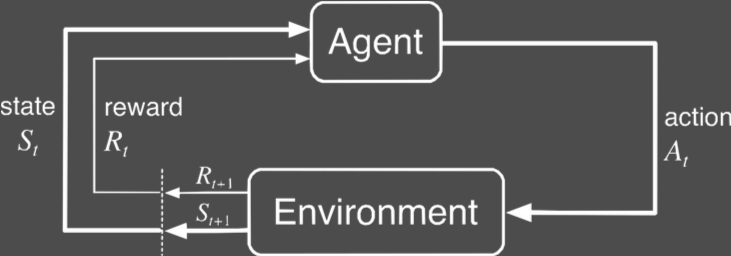

O fluxo de interação entre um agente e um ambiente durante alguns episódios é codificado da seguinte forma:

In [3]:
from typing import Any
from tqdm import tqdm



def run_interaction(env: gym.Env, agent: Any, n_episodes: int) -> list[float]:
    """
    Executa o loop de interação entre o agente e o ambiente Gymnasium.

    Esta função coordena o ciclo de vida de múltiplos episódios, incluindo a coleta de experiências, a execução de ações
    e a atualização da política do agente com base no retorno do ambiente.

    Args:
        env (gym.Env): O ambiente de simulação seguindo a API do Gymnasium.
        agent (Any): O agente de Reinforcement Learning (deve possuir os métodos "get_action" e "update").
        n_episodes (int): Quantidade de episódios para execução.

    Returns:
        list[float]: Uma lista contendo a recompensa total acumulada em cada episódio.
    """
    rewards: list[float] = []

    for _ in tqdm(range(n_episodes), desc="Treinando"):

        # Reinicia o ambiente para o estado inicial
        state, info = env.reset()
        done: bool = False
        total_reward: float = 0.0


        while not done:
            # Seleção de ação baseada na política do agente
            action = agent.get_action(state)

            # Execução da ação no ambiente
            next_state, reward, terminated, truncated, info = env.step(action)

            # O episódio termina se o agente atingir um estado terminal (terminated) ou o limite de tempo (truncated)
            done = terminated or truncated

            # O agente processa a transição (S, A, R, S') para aprender
            agent.update(state, action, reward, done, next_state)

            # Transição de estado e acúmulo de recompensa
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return rewards

## Random Agent

In [4]:
from typing import Any



class RandomAgent:
    """
    Agente baseline que interage com o ambiente através de escolhas aleatórias.

    Este agente não possui memória ou capacidade de aprendizado, servindo apenas como um ponto de referência (baseline)
    para validar a implementação do fluxo de treinamento e comparar o desempenho de algoritmos de RL.
    """

    def __init__(self, action_space: gym.spaces.Space):
        """
        Inicializa o agente aleatório.

        Args:
            action_space (gym.spaces.Space): O espaço de ações do ambiente, utilizado para amostrar ações válidas.
        """
        self.action_space: gym.spaces.Space = action_space


    def get_action(self, state: Any) -> Any:
        """
        Seleciona uma ação aleatória independentemente do estado.

        Args:
            state (Any): A observação/estado atual do ambiente. Ignorado por este agente.

        Returns:
            Any: Uma ação válida sorteada aleatoriamente do espaço de ações.
        """
        return self.action_space.sample()


    def update(self, state: Any, action: Any, reward: float, done: bool, next_state: Any) -> None:
        """
        Interface de atualização do agente.

        Para o RandomAgent, este método não realiza operações, visto que o agente não aprende com a experiência.

        Args:
            state (Any): Estado anterior à ação.
            action (Any): Ação que foi executada.
            reward (float): Recompensa recebida após a ação.
            done (bool): Indica se o episódio foi encerrado.
            next_state (Any): Novo estado após a execução da ação.
        """
        pass

Treinando: 100%|██████████| 10000/10000 [00:01<00:00, 6283.41it/s]


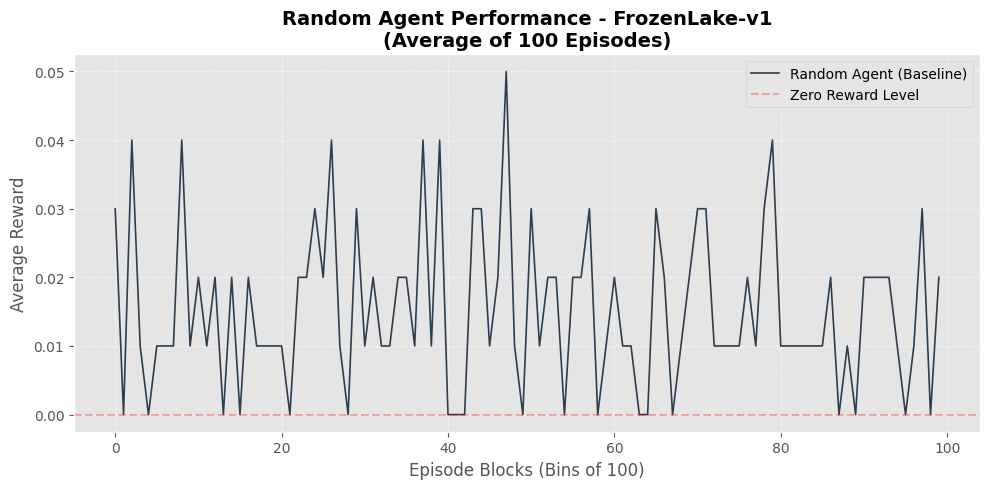

In [39]:
import numpy as np
from matplotlib import pyplot as plt



# Configuração de estilo para um visual limpo e profissional
plt.style.use('ggplot')

n_episodes = int(1e4)
window_size = 100

# Execução da interação
rewards = run_interaction(env, RandomAgent(env.action_space), n_episodes)

# Processamento de dados
mean_rewards = np.array(rewards).reshape(-1, window_size).mean(axis=-1)

# Criação do gráfico com dimensões otimizadas
plt.figure(figsize=(10, 5))
plt.plot(mean_rewards, label='Random Agent (Baseline)', color='#2c3e50', linewidth=1.2)

# Títulos e Eixos (Labels)
plt.title(f'Random Agent Performance - FrozenLake-v1\n(Average of {window_size} Episodes)', fontsize=14, fontweight='bold')
plt.xlabel('Episode Blocks (Bins of 100)', fontsize=12)
plt.ylabel('Average Reward', fontsize=12)

# Adicionando elementos informativos
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Zero Reward Level')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True)

# Ajuste fino para não cortar rótulos ao salvar
plt.tight_layout()

**Desempenho do Agente Aleatório**

A imagem apresenta o comportamento esperado de um Random Agent em um ambiente de Aprendizado por Reforço. Através da análise do gráfico de média móvel, é possível extrair as seguintes conclusões:

* **Ausência de Aprendizado:** A curva não apresenta uma tendência de crescimento ao longo dos 10.000 episódios. A recompensa média permanece flutuando em patamares muito baixos (entre 0.00 e 0.05), confirmando que o agente não está otimizando sua política com base na experiência.

* **Estocasticidade e Recompensa Esparsa:** As oscilações bruscas (picos e vales) representam a natureza aleatória do agente. Em ambientes como o FrozenLake, ganhar uma recompensa agindo aleatoriamente é um evento de baixa probabilidade, ocorrendo apenas por puro acaso.

* **Papel como Baseline:** Este gráfico serve como um marco zero (baseline). Ele demonstra que qualquer algoritmo de aprendizado posterior (como o Q-Learning) deve apresentar uma curva de crescimento consistente acima desses valores para ser considerado eficaz.

O gráfico comprova que a simples repetição de tentativas, sem uma estrutura de atualização de valores (como a Equação de Bellman), é insuficiente para resolver problemas de tomada de decisão sequencial.


## Q-learning Agent


### O que é Q-Learning?

O Q-Learning é um algoritmo de **Aprendizado por Reforço Diferencial Temporal (TD)**. Ele busca aprender uma função de valor-ação $Q(s, a)$, que representa o retorno esperado ao tomar uma ação $a$ em um estado $s$ e seguir a política ótima a partir daí.

A essência do Q-Learning é a **Equação de Bellman**:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Onde $\alpha$ é a taxa de aprendizado e $\gamma$ o fator de desconto.
<br>


### **Comparação de Abordagens**

#### RL Planning vs. Learning

| Característica | Value Iteration | Policy Evaluation | Q-Learning | SARSA |
| --- | --- | --- | --- | --- |
| **Categoria** | Model-Based (Planning) | Model-Based (Planning) | Model-Free (Learning) | Model-Free (Learning) |
| **Conhece o Ambiente?** | Sim (Sabe as probabilidades) | Sim (Sabe as probabilidades) | Não (Aprende interagindo) | Não (Aprende interagindo) |
| **Objetivo** | Encontrar a Política Ótima | Medir a qualidade de uma política | Encontrar a Política Ótima | Encontrar a Política Ótima |
| **Tipo de Atualização** | Off-Policy | N/A (Foco em predição) | Off-Policy | On-Policy |
| **Equação Base** | Bellman Optimality | Bellman Expectation | Bellman Optimality (TD) | Bellman Expectation (TD) |

<br>


#### 1. **Métodos Baseados em Modelo (MDPs Conhecidos)**

Nesses métodos, o agente conhece a "física" do mundo (o **MDP**), ou seja, ele sabe exatamente qual a probabilidade de ir para o estado $s'$ ao tomar a ação $a$.

* **Value Iteration:** É um algoritmo de busca da política ótima. Ele melhora iterativamente a função de valor de estado ($V$) assumindo que, em cada passo, o agente escolherá a melhor ação possível (ganância). É eficiente, mas exige o conhecimento completo do modelo.
* **Policy Evaluation:** Não busca a política ótima, mas sim **estima o valor** de uma política específica já existente. Ele responde à pergunta: "Se eu seguir sempre este caminho, qual será meu retorno esperado?". É um passo fundamental para o algoritmo de *Policy Iteration*.

<br>



#### 2. **Métodos Livres de Modelo (Aprendizado por Diferença Temporal)**

O agente não conhece as probabilidades de transição, mas aprende fazendo, através do erro da **Diferença Temporal (TD)**.

* **Q-Learning (Off-Policy):** O agente aprende o valor da política ótima independentemente das ações que ele está tomando durante a exploração. Ele é "ousado": ao atualizar o valor de um estado, ele olha para o melhor valor futuro possível ($\max Q$), mesmo que a próxima ação escolhida seja aleatória (devido ao $\epsilon$-greedy).

* **SARSA (On-Policy):** O nome vem de **S**tate-**A**ction-**R**eward-**S**tate-**A**ction. Ele atualiza o valor $Q$ com base na ação que o agente **realmente** escolheu. Se o agente decidir explorar um caminho perigoso por causa do $\epsilon$-greedy, o SARSA incluirá esse risco na sua média. Por isso, é considerado mais "cauteloso" que o Q-Learning.

<br>


### **Justificativa da Escolha: Por que usar o Q-Learning no FrozenLake?**

A escolha do **Q-Learning** justifica-se por alguns pilares técnicos:

1. **Natureza Model-Free:** Diferente de métodos como **Value Iteration** ou **Policy Evaluation**, que exigem o conhecimento explícito das probabilidades de transição $P(s'|s,a)$ e da função de recompensa $R(s,a)$, o **Q-Learning é Model-Free**. Como o ambiente utilizado é o do Gymnasium, o FrozenLake é tratado como uma caixa-preta onde apenas as entradas (ações) e saídas (observações/recompensas) são conhecidas. Isso impossibilita o uso de técnicas de planejamento de programação dinâmica sem antes estimar um modelo estatístico completo do ambiente.

2. **Robustez à Estocasticidade:** O FrozenLake, na versão `is_slippery=True`, possui uma dinâmica complexa onde a ação executada nem sempre resulta no movimento pretendido. O Q-Learning lida com essa estocasticidade de forma robusta, pois sua regra de atualização baseia-se na Diferença Temporal (TD), permitindo que o agente ajuste seus valores $Q$ com base no que realmente aconteceu, e não em uma probabilidade teórica pré-definida.

3. **Convergência para a Política Ótima:** Por ser *Off-Policy*, o Q-Learning foca diretamente em aprender os valores das melhores ações. No FrozenLake, onde a recompensa é esparsa (você só ganha no final), essa característica ajuda a propagar a recompensa do objetivo de volta para o início de forma mais agressiva.

4. **Ambiente Seguro para Exploração:** No FrozenLake, não há "custos de vida" ou punições catastróficas (como quebrar um robô real). Cair em um buraco apenas reinicia o episódio. Em ambientes seguros assim, o Q-Learning é preferível ao SARSA, pois encontra o caminho ótimo mais rapidamente sem se preocupar excessivamente com o risco das ações exploratórias.

In [6]:
import random
from collections import defaultdict



class QLearningAgent:
    """
    Agente de Aprendizado por Reforço que utiliza o algoritmo Q-Learning.

    O algoritmo é model-free e off-policy, aprendendo o valor de cada par estado-ação para encontrar
    a política ótima em um Processo de Decisão de Markov (MDP).
    """

    def __init__(
        self,
        action_space: gym.spaces.Discrete,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float,
    ):
        """
        Inicializa o agente com hiperparâmetros e tabela Q.

        Args:
            action_space (gym.spaces.Discrete): Espaço de ações do ambiente.
            learning_rate (float): Taxa de aprendizado (alpha).
            initial_epsilon (float): Valor inicial para a estratégia epsilon-greedy.
            epsilon_decay (float): Valor subtraído do epsilon a cada episódio.
            final_epsilon (float): Valor mínimo permitido para o epsilon.
            discount_factor (float): Fator de desconto para recompensas futuras (gamma).
        """

        self.action_space: gym.spaces.Discrete = action_space
        self.lr: float = learning_rate
        self.discount_factor: float = discount_factor

        # Q-table inicializada com zeros
        self.q_values: dict[int, np.ndarray] = defaultdict(lambda: np.zeros(action_space.n))

        self.epsilon: float = initial_epsilon
        self.epsilon_decay: float = epsilon_decay
        self.final_epsilon: float = final_epsilon


    def get_action(self, state: int) -> int:
        """
        Seleciona uma ação usando a estratégia epsilon-greedy.

        Args:
            state (int): O estado atual observado no ambiente.

        Returns:
            int: A ação a ser executada (0 a 3 no FrozenLake).
        """
        if random.uniform(0, 1) < self.epsilon:
            return int(self.action_space.sample())
        else:
            return int(np.argmax(self.q_values[state]))


    def update(self, state: int, action: int, reward: float, done: bool, next_state: int,) -> None:
        """
        Atualiza o valor Q para o par (estado, ação) via Diferença Temporal (TD).

        Fórmula: Q(s,a) = Q(s,a) + alpha * [R + gamma * max(Q(s',a')) - Q(s,a)]

        Args:
            state (int): Estado anterior.
            action (int): Ação executada.
            reward (float): Recompensa recebida.
            done (bool): Indica se o episódio terminou.
            next_state (int): Novo estado após a ação.
        """

        # Estimativa do valor futuro (max_a Q(s', a'))
        future_optimal_value = np.max(self.q_values[next_state])

        # Alvo da Diferença Temporal (TD Target)
        td_target = reward + self.discount_factor * future_optimal_value

        # Erro da Diferença Temporal (TD Error)
        td_error = td_target - self.q_values[state][action]

        # Atualização da Q-table
        self.q_values[state][action] += self.lr * td_error

        if done:
            self.decay_epsilon()


    def decay_epsilon(self) -> None:
        """
        Reduz gradualmente o valor de epsilon para diminuir a exploração ao longo do tempo.
        """
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

In [37]:
# Definição de hiperparametros
n_episodes = 10000
learning_rate = 0.035
start_epsilon = 1
epsilon_decay = start_epsilon / (n_episodes * 0.75)
final_epsilon = 0.0001
discount_factor = 0.99


# Chamada do agente
agent = QLearningAgent(
    env.action_space,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
    discount_factor=discount_factor
)

Treinando: 100%|██████████| 10000/10000 [00:06<00:00, 1543.15it/s]


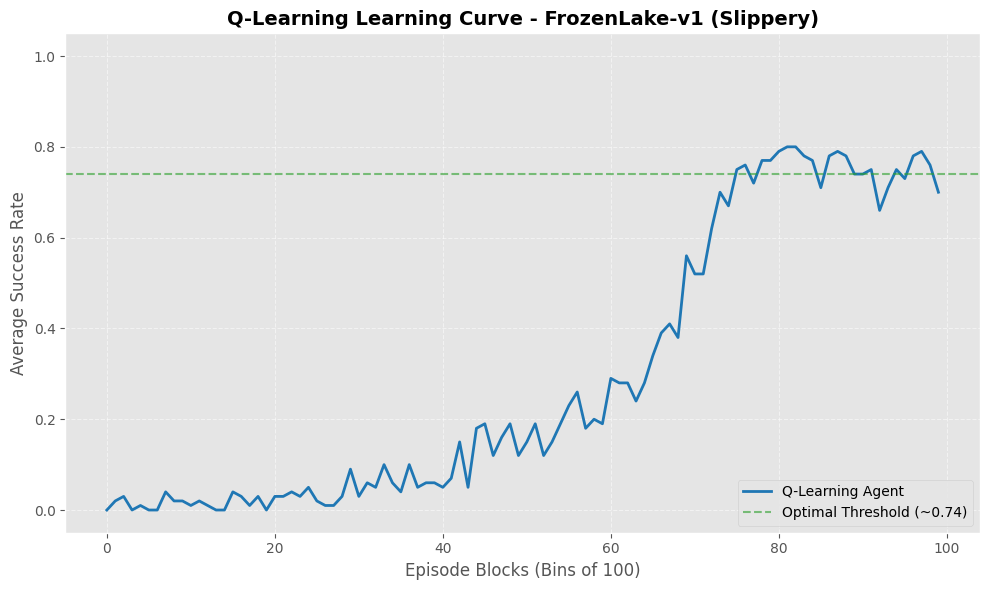

In [38]:
# Configuração de estilo
plt.style.use('ggplot')

# Parâmetros de suavização
window_size = 100

# Treinamento e coleta de recompensas
rewards = run_interaction(env, agent, n_episodes)

# Processamento para média móvel
mean_rewards = np.array(rewards).reshape(-1, window_size).mean(axis=-1)

# Criação do gráfico profissional
plt.figure(figsize=(10, 6))
plt.plot(mean_rewards, label='Q-Learning Agent', color='#1f77b4', linewidth=2)

# Linha de referência da Política Ótima (Benchmark para FrozenLake Slippery)
plt.axhline(y=0.74, color='#2ca02c', linestyle='--', alpha=0.6, label='Optimal Threshold (~0.74)')

# Títulos e Eixos em Inglês
plt.title('Q-Learning Learning Curve - FrozenLake-v1 (Slippery)', fontsize=14, fontweight='bold')
plt.xlabel('Episode Blocks (Bins of 100)', fontsize=12)
plt.ylabel('Average Success Rate', fontsize=12)

# Detalhes visuais
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True)
plt.ylim(-0.05, 1.05) # Mantém a escala de 0 a 100% visível

# Finalização
plt.tight_layout()

In [34]:
import pandas as pd

# Transformando a Q-Table em um DataFrame para visualização tabular
q_df = pd.DataFrame.from_dict(agent.q_values, orient='index', columns=['Esquerda', 'Baixo', 'Direita', 'Cima'])

print("Visualização da Q-Table Final:")
display(q_df.sort_index())

Visualização da Q-Table Final:


,Esquerda,Baixo,Direita,Cima
0,0.581708,0.505238,0.506146,0.492560
1,0.303920,0.315057,0.299479,0.533660
2,0.355942,0.345979,0.329953,0.500199
3,0.137735,0.133442,0.125760,0.475414
4,0.596807,0.389149,0.381462,0.370240
5,0.000000,0.000000,0.000000,0.000000
6,0.256360,0.228667,0.376880,0.099237
7,0.000000,0.000000,0.000000,0.000000
8,0.366315,0.427899,0.391105,0.625751
9,0.431809,0.663663,0.422018,0.457872


### **Conclusão**

#### 1. **Visão Geral do Desempenho**

O agente demonstrou uma evolução clara, superando significativamente o baseline do **Random Agent**:

* **Random Agent:** Manteve uma recompensa média estagnada próxima de zero (entre $0.00$ e $0.05$), evidenciando a dificuldade do ambiente com recompensas esparsas e transições estocásticas.
* **Q-learning Agent:** Partindo de um desempenho nulo, o agente atingiu uma taxa de sucesso de aproximadamente **80%** ao final dos 10.000 episódios.

<br>

#### 2. **Análise da Curva de Aprendizado**

A curva de recompensas médias apresenta três fases distintas que validam a eficácia dos hiperparâmetros escolhidos:

1. **Fase de Exploração (Episódios 0 - 2.000):** A recompensa permanece baixa enquanto o $\epsilon$ está alto. O agente está mapeando o grid aleatoriamente, caindo frequentemente em buracos, mas começando a registrar as primeiras transições bem-sucedidas para a meta.
2. **Fase de Aprendizado Acelerado (Episódios 2.000 - 7.500):** Há um crescimento quase exponencial no retorno médio. Isso indica que os valores de  estão sendo propagados de trás para frente (da meta para o início) através da **Diferença Temporal (TD)**. O decaimento gradual do epsilon permite que o agente utilize cada vez mais o conhecimento adquirido.
3. **Convergência e Estabilização (Episódios 7.500 - 10.000):** Com o epsilon atingindo o valor final ($0.0001$), o agente entra em modo de explotação quase pura. A curva estabiliza em torno de $0.75$ a $0.80$, o que representa o **teto de desempenho** para a versão `is_slippery=True`.

<br>

#### 3. **Impacto dos Hiperparâmetros**

A escolha técnica dos valores foi fundamental para o sucesso do modelo:

* **Fator de Desconto (γ):** Por ser uma recompensa esparsa (recebida apenas no final), um γ alto garante que o valor da meta chegue ao estado inicial com força suficiente para guiar o agente.
* **Taxa de Aprendizado:** Um valor conservador foi adequado para o ambiente estocástico. Como as ações podem falhar devido ao gelo, um valor baixo evita que um "erro de percurso" aleatório destrua os valores $Q$ já aprendidos, garantindo estabilidade.
* **Decaimento do Epsilon:** O ajuste para durar 75% do treino foi preciso, garantindo tempo suficiente de exploração sem sacrificar a fase final de consolidação da política ótima.

<br>

#### 4. **Limitações Ambientais e Otimalidade**

É importante notar que o agente não atingiu 100% de sucesso, o que é **tecnicamente esperado**. No FrozenLake com gelo escorregadio, existem estados onde, estatisticamente, o agente pode ser levado a um buraco independentemente da ação escolhida. Uma taxa de ≈80% é considerada a **Política Ótima ($\pi^*$)** para este MDP específico.

<br>

#### 5. **Interpretação da Q-Table do Agente**

A **Q-Table** é uma estrutura de dados onde o agente armazena o conhecimento adquirido. Cada célula da tabela representa o valor Q, que é a recompensa total esperada ao tomar uma ação específica em um determinado estado e seguir a política ótima dali em diante.

* **Linhas (Índice):** Representam os 16 estados do grid (0 a 15).

* **Colunas:** Representam as 4 ações possíveis: Esquerda (0), Baixo (1), Direita (2) e Cima (3).

Ao final do treinamento, as ações com os maiores valores em cada linha indicam o caminho que o agente considera mais seguro e vantajoso para chegar à meta. Valores iguais a zero em estados visitados geralmente indicam caminhos que levam a buracos ou zonas de recompensa nula.